<a href="https://colab.research.google.com/github/KishoreKumar477/ml-supervised/blob/main/CustomerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# Download latest version
path = kagglehub.dataset_download("yasserh/customer-segmentation-dataset")

print("Path to dataset files:", path)
print("Files in downloaded directory:", os.listdir(path))
df = pd.read_excel(path + "/Online Retail.xlsx")
df.head()

Using Colab cache for faster access to the 'customer-segmentation-dataset' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-dataset
Files in downloaded directory: ['Online Retail.xlsx']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.shape

(541909, 8)

In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
df.Quantity.sort_values()

,Quantity
540422,-80995
61624,-74215
225529,-9600
225530,-9600
4287,-9360
...,...
421632,4800
74614,5568
502122,12540
61619,74215


In [7]:
df[df.Quantity<0].sort_values(by='Quantity')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
225529,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
225530,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom
...,...,...,...,...,...,...,...,...
540091,C581466,21232,STRAWBERRY CERAMIC TRINKET POT,-1,2011-12-08 19:20:00,1.25,13883.0,United Kingdom
1979,C536548,22333,RETROSPOT PARTY BAG + STICKER SET,-1,2010-12-01 14:33:00,1.65,12472.0,Germany
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1977,C536548,22654,DELUXE SEWING KIT,-1,2010-12-01 14:33:00,5.95,12472.0,Germany


In [8]:
df[df.Quantity<0].value_counts()

InvoiceNo  StockCode  Description                         Quantity  InvoiceDate          UnitPrice  CustomerID  Country       
C543611    82483      WOOD 2 DRAWER CABINET WHITE FINISH  -1        2011-02-10 14:38:00  4.95       17850.0     United Kingdom    4
C538341    22730      ALARM CLOCK BAKELIKE IVORY          -1        2010-12-10 14:03:00  3.75       15514.0     United Kingdom    3
           22725      ALARM CLOCK BAKELIKE CHOCOLATE      -1        2010-12-10 14:03:00  3.75       15514.0     United Kingdom    3
           22976      CIRCUS PARADE CHILDRENS EGG CUP     -12       2010-12-10 14:03:00  1.25       15514.0     United Kingdom    3
           22727      ALARM CLOCK BAKELIKE RED            -2        2010-12-10 14:03:00  3.75       15514.0     United Kingdom    2
                                                                                                                                 ..
C551464    22745      POPPY'S PLAYHOUSE BEDROOM           -6        2011-04-28 16:15:00  2.10       13085.0     United Kingdom    1
           22746      POPPY'S PLAYHOUSE LIVINGROOM        -6        2011-04-28 16:15:00  2.10       13085.0     United Kingdom    1
           22748      POPPY'S PLAYHOUSE KITCHEN           -6        2011-04-28 16:15:00  2.10       13085.0     United Kingdom    1
C551465    21714      CITRONELLA CANDLE GARDEN POT        -3        2011-04-28 16:17:00  1.25       14640.0     United Kingdom    1
C551463    23152      IVORY SWEETHEART WIRE LETTER RACK   -2        2011-04-28 16:13:00  3.75       13534.0     United Kingdom    1
Name: count, Length: 8872, dtype: int64

In [9]:
df.isnull().sum()
df = df.dropna(subset=['CustomerID'])

In [10]:
df=df[(df['Quantity']>0) & (df['UnitPrice']>0)]

In [11]:
df['TotalPrice']=df['Quantity'] * df['UnitPrice']

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [13]:
df['CustomerID'].nunique()

4338

creating rfm (recency frequency monetary)

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [17]:
rfm
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

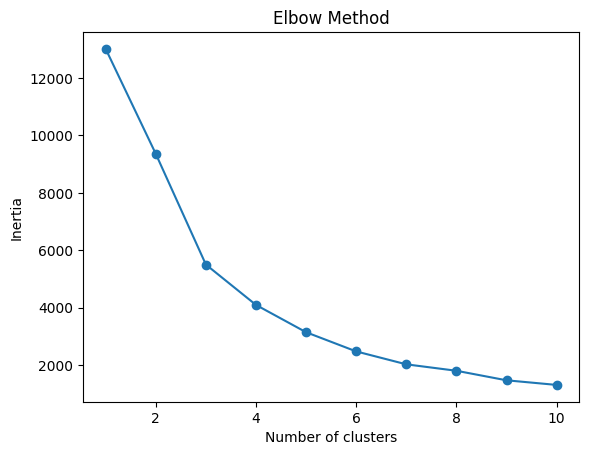

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia=[]
for i in range(1,11):
  Km=KMeans(n_clusters=i,random_state=42)
  Km.fit(rfm_scaled)
  inertia.append(Km.inertia_)

plt.plot(range(1,11),inertia,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

##K=3 from Elbow Method


In [21]:
Km=KMeans(n_clusters=3,random_state=42)
predicted=Km.fit_predict(rfm_scaled)
predicted
rfm['Cluster']=predicted

In [22]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,40.983906,4.852677,2012.111620
1,246.023788,1.582800,631.141410
2,7.142857,80.214286,122888.407143


🔴 Cluster 2 → Lost / Inactive Customers

Recency: 248 (VERY HIGH) ❌

Frequency: 1.55 (LOW) ❌

Monetary: 630 (LOW) ❌

👉 These customers:

Haven’t purchased in a long time

Barely bought anything
Low value

💡 Conclusion:

➡️ Churned customers

🎯 Strategy:

Don’t spend much money here

Maybe send cheap reactivation emails

🟡 Cluster 0 → Occasional Customers

Recency: 40 (MEDIUM)
Frequency: 4.8 (LOW-MEDIUM)
Monetary: 2012 (MEDIUM)

👉 These customers:
Buy sometimes
Not super loyal
Moderate value

💡 Conclusion:
➡️ Regular but not loyal customers

🎯 Strategy:
Offer discounts / bundles
Push them toward becoming frequent buyers


🟢 Cluster 1 → Elite / Whales (Top 1%)
Recency: 7 (VERY LOW) 🔥
Frequency: 80 (EXTREME) 🔥
Monetary: 127,338 (INSANE) 🔥

👉 These are:
Extremely active
Extremely high spenders

💡 Conclusion:
➡️ Top premium customers (business backbone)

⚠️ Note:
This cluster is usually very small
Might even be outliers

🎯 Strategy:
Dedicated account management
Premium support
Exclusive deals

#Final Insight

"The clustering reveals a strong customer segmentation where a small percentage of customers (Cluster 1) contributes disproportionately to revenue, indicating a Pareto-like distribution. This suggests prioritizing retention strategies for high-value clusters while minimizing cost on low-value segments."